## 0 — Environment Setup

In [23]:
import os
os.environ['GLOG_minloglevel']      = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL']  = '3'
os.environ['GRPC_VERBOSITY']        = 'ERROR'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers, Model, Input
from keras.callbacks import (ModelCheckpoint, EarlyStopping,
                              ReduceLROnPlateau, TensorBoard, CSVLogger)

# ── GPU setup ──────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU ready  : {gpus[0].name}")
else:
    print("⚠️  No GPU found — training on CPU (will be slow)")

print(f"✅ TensorFlow : {tf.__version__}")
print(f"✅ Keras      : {keras.__version__}")
np.random.seed(42)
tf.random.set_seed(42)


✅ GPU ready  : /physical_device:GPU:0
✅ TensorFlow : 2.21.0
✅ Keras      : 3.12.2


## 1 — Configuration

In [24]:
PROJECT_ROOT   = Path('..').resolve()
AUGMENTED_DIR  = PROJECT_ROOT / 'UAE-dataset' / 'processed' / 'augmented'
SPLITS_DIR     = PROJECT_ROOT / 'UAE-dataset' / 'processed' / 'splits'
MODELS_DIR     = PROJECT_ROOT / 'models' / 'trained'
LOGS_DIR       = PROJECT_ROOT / 'models' / 'logs'

for d in [MODELS_DIR, LOGS_DIR, SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Sequence / model constants (must match preprocess_data.ipynb) ──────────────
SEQ_LEN      = 60
N_KEYPOINTS  = 75
N_DIMS       = 2

# ── ST-GCN hyperparameters ────────────────────────────────────────────────────
GCN_CHANNELS   = [64, 128]      # output channels per GCN layer
GCN_DROPOUT    = 0.4

# ── BiLSTM hyperparameters ────────────────────────────────────────────────────
LSTM_UNITS     = 128
LSTM_LAYERS    = 2
LSTM_DROPOUT   = 0.5

# ── Fusion head ───────────────────────────────────────────────────────────────
FUSION_UNITS   = 512
FUSION_DROPOUT = 0.4

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE     = 32
EPOCHS         = 150
LR_INITIAL     = 1e-3
LR_MIN         = 1e-6
LABEL_SMOOTHING= 0.1
VAL_SPLIT      = 0.15
TEST_SPLIT     = 0.10

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M')
print(f"Run ID : {RUN_ID}")
print(f"Data   : {AUGMENTED_DIR}")


Run ID : 20260512_2317
Data   : /home/livex/projects/Sign2Chat/UAE-dataset/processed/augmented


## 2 — Dataset Loading
Auto-discovers all `.npy` files — safe to re-run after adding more classes.


✅ Loaded dataset
   Samples       : 37,350
   Classes       : 1245
   Shape per seq : (60, 75, 2)
   X dtype       : float32
   X range       : [-13.297, 12.860]
   Samples/class : 30.0 avg


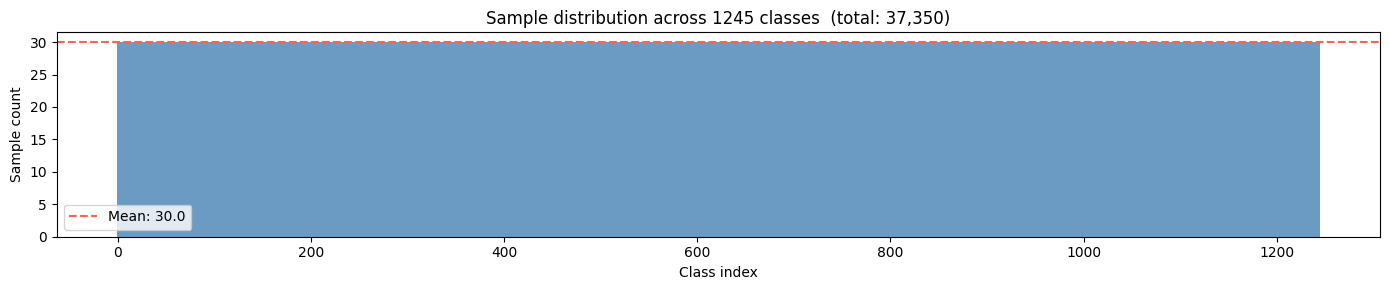

In [25]:
def load_dataset(augmented_dir: Path):
    """
    Load all augmented .npy files.
    Filename format: {class_name}_aug_{N:02d}.npy
    Returns X (N, 60, 75, 2), y (N,) string labels, and label encoder.
    """
    npy_files = sorted(augmented_dir.glob('*.npy'))
    assert len(npy_files) > 0, f"No .npy files found in {augmented_dir}"

    X, y = [], []
    for f in npy_files:
        # Strip aug suffix: 'Alphabets_01_Alif_aug_03' -> 'Alphabets_01_Alif'
        parts = f.stem.rsplit('_aug_', 1)
        class_name = parts[0] if len(parts) == 2 else f.stem
        seq = np.load(f).astype(np.float32)
        if seq.shape != (SEQ_LEN, N_KEYPOINTS, N_DIMS):
            continue   # skip malformed files silently
        X.append(seq)
        y.append(class_name)

    X = np.stack(X, axis=0)
    y = np.array(y)

    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    return X, y_enc, le


X, y, label_encoder = load_dataset(AUGMENTED_DIR)
NUM_CLASSES = len(label_encoder.classes_)

print(f"✅ Loaded dataset")
print(f"   Samples       : {len(X):,}")
print(f"   Classes       : {NUM_CLASSES}")
print(f"   Shape per seq : {X.shape[1:]}")
print(f"   X dtype       : {X.dtype}")
print(f"   X range       : [{X.min():.3f}, {X.max():.3f}]")
print(f"   Samples/class : {len(X)/NUM_CLASSES:.1f} avg")

# ── Class distribution plot ───────────────────────────────────────────────────
counts = pd.Series(y).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(len(counts)), counts.values, width=1.0, color='steelblue', alpha=0.8)
ax.set_xlabel("Class index"); ax.set_ylabel("Sample count")
ax.set_title(f"Sample distribution across {NUM_CLASSES} classes  (total: {len(X):,})")
ax.axhline(counts.mean(), color='tomato', linestyle='--', label=f'Mean: {counts.mean():.1f}')
ax.legend(); plt.tight_layout(); plt.show()


## 3 — Train / Validation / Test Split

In [26]:
# Stratified split: preserves class balance in all three sets
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=42)

val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio, stratify=y_trainval, random_state=42)

# One-hot encode
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Train : {len(X_train):>5}  samples")
print(f"Val   : {len(X_val):>5}  samples")
print(f"Test  : {len(X_test):>5}  samples")
print()
print(f"Train X shape : {X_train.shape}")

# Save label map for inference use
label_map = {int(i): str(name) for i, name in enumerate(label_encoder.classes_)}
with open(SPLITS_DIR / 'label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2, ensure_ascii=False)
print(f"✅ label_map.json saved  ({NUM_CLASSES} classes)")


Train : 28012  samples
Val   :  5603  samples
Test  :  3735  samples

Train X shape : (28012, 60, 75, 2)
✅ label_map.json saved  (1245 classes)


## 4 — Skeleton Graph Adjacency Matrix
The ST-GCN needs an adjacency matrix encoding which joints are connected.  
We use 3 edge types: **spatial** (anatomical), **temporal** (same joint across frames), **cross-body** (hand ↔ torso).


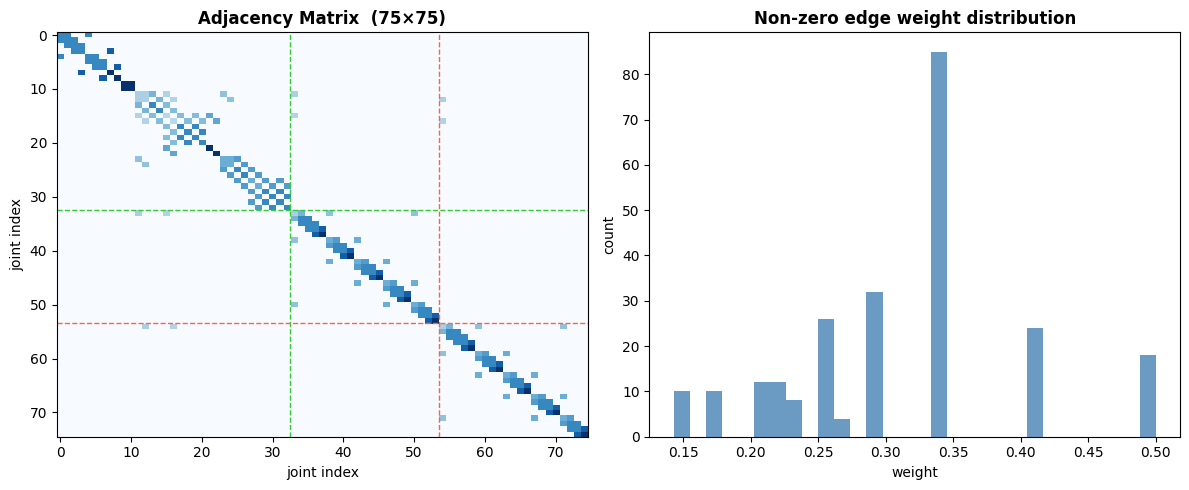

Adjacency matrix : (75, 75)
Non-zero edges   : 241
Weight range     : [0.1429, 0.5000]


In [27]:
def build_adjacency(n_joints: int = N_KEYPOINTS) -> np.ndarray:
    """
    Build normalized adjacency matrix A of shape (N_KEYPOINTS, N_KEYPOINTS).
    Combines spatial (anatomical) + cross-body edges.
    Temporal edges are handled implicitly by the sequence dimension.
    """
    A = np.zeros((n_joints, n_joints), dtype=np.float32)

    # ── Pose connections (0-32) ───────────────────────────────────────────────
    pose_edges = [
        (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
        (9,10),(11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
        (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
        (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28),
        (27,29),(28,30),(29,31),(30,32),(27,31),(28,32)
    ]
    hand_edges = [
        (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
        (5,9),(9,10),(10,11),(11,12),(9,13),(13,14),(14,15),(15,16),
        (13,17),(17,18),(18,19),(19,20),(0,17)
    ]
    LHAND_OFF, RHAND_OFF = 33, 54

    for a, b in pose_edges:
        A[a, b] = A[b, a] = 1.0
    for a, b in hand_edges:
        A[LHAND_OFF+a, LHAND_OFF+b] = A[LHAND_OFF+b, LHAND_OFF+a] = 1.0
        A[RHAND_OFF+a, RHAND_OFF+b] = A[RHAND_OFF+b, RHAND_OFF+a] = 1.0

    # ── Cross-body: connect wrists to shoulders ───────────────────────────────
    # left wrist(15) → left shoulder(11), right wrist(16) → right shoulder(12)
    # lhand wrist(33) → pose left wrist(15)
    # rhand wrist(54) → pose right wrist(16)
    cross_edges = [(15, 11), (16, 12), (33, 15), (54, 16),
                   (33, 11), (54, 12)]
    for a, b in cross_edges:
        A[a, b] = A[b, a] = 1.0

    # ── Self-connections ──────────────────────────────────────────────────────
    np.fill_diagonal(A, 1.0)

    # ── Symmetric normalization: D^{-1/2} A D^{-1/2} ─────────────────────────
    D = np.diag(A.sum(axis=1) ** -0.5)
    A_norm = D @ A @ D

    return A_norm.astype(np.float32)


A = build_adjacency()
A_tensor = tf.constant(A, dtype=tf.float32)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(A, cmap='Blues', aspect='auto')
axes[0].axvline(32.5, color='limegreen', lw=1, linestyle='--')
axes[0].axvline(53.5, color='tomato',    lw=1, linestyle='--')
axes[0].axhline(32.5, color='limegreen', lw=1, linestyle='--')
axes[0].axhline(53.5, color='tomato',    lw=1, linestyle='--')
axes[0].set_title(f"Adjacency Matrix  ({N_KEYPOINTS}×{N_KEYPOINTS})", fontweight='bold')
axes[0].set_xlabel("joint index"); axes[0].set_ylabel("joint index")

axes[1].hist(A[A > 0].flatten(), bins=30, color='steelblue', alpha=0.8)
axes[1].set_title("Non-zero edge weight distribution", fontweight='bold')
axes[1].set_xlabel("weight"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"Adjacency matrix : {A.shape}")
print(f"Non-zero edges   : {(A > 0).sum()}")
print(f"Weight range     : [{A[A>0].min():.4f}, {A.max():.4f}]")


## 5 — Model Architecture

### Two-Stream Design
- **Stream A (ST-GCN):** Graph convolutions over the 75-joint skeleton — captures *what shape* the hands/body make
- **Stream B (BiLSTM):** Recurrent layers over hand velocity — captures *how* the sign moves
- **Fusion:** Concatenate both → FC head → softmax


In [28]:
from logging import config

import keras.ops as kops   # Keras 3 — use keras.ops instead of tf.* in model graph

# ── ST-GCN layer ──────────────────────────────────────────────────────────────
class STGCNLayer(layers.Layer):
    """
    Spatial-Temporal Graph Convolutional layer.
    Input : (B, T, N, C_in)
    Output: (B, T, N, C_out)

    Fix (Keras 3): all ops inside call() use keras.ops, not tf.*
    The adjacency matrix is stored as a plain numpy array and converted
    inside call() via kops.cast — safe for symbolic KerasTensors.
    """
    def __init__(self, out_channels, A, dropout=0.4, **kwargs):
        super().__init__(**kwargs)
        self.A_np = A.astype('float32')   # store as numpy; cast at call time
        self.out_channels = out_channels
        self.dropout_rate = dropout

        self.W        = None
        self.bn       = layers.BatchNormalization()
        self.relu     = layers.Activation('relu')
        self.drop     = layers.Dropout(dropout)
        self.res_conv = None

    def build(self, input_shape):
        C_in = input_shape[-1]
        self.W = self.add_weight(
            name='W', shape=(C_in, self.out_channels),
            initializer='glorot_uniform', trainable=True)
        if C_in != self.out_channels:
            self.res_conv = layers.Dense(self.out_channels, use_bias=False)
        super().build(input_shape)

    def call(self, x, training=False):
        # x: (B, T, N, C)
        residual = x
        A = kops.cast(self.A_np, x.dtype)            # safe symbolic cast
        Ax  = kops.einsum('btnc,nm->btmc', x, A)     # graph conv over N
        out = kops.einsum('btnc,cd->btnd', Ax, self.W)  # project channels
        out = self.bn(out, training=training)
        out = self.relu(out)
        out = self.drop(out, training=training)
        if self.res_conv is not None:
            residual = self.res_conv(x)
        return out + residual
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'out_channels': self.out_channels,
            'A':            self.A_np.tolist(),   # numpy → list (JSON serializable)
            'dropout':      self.dropout_rate,
        })
        return config


# ── Keras 3 compatible layers for transpose + velocity ────────────────────────
class TransposeLayer(layers.Layer):
    """Wraps kops.transpose so it's safe inside a Functional model."""
    def call(self, x):
        return kops.transpose(x, [0, 3, 1, 2])   # (B,T,N,C) → (B,C,T,N)

class VelocityLayer(layers.Layer):
    """Frame-to-frame velocity with zero-prepend, Keras 3 safe."""
    def call(self, x):
        # x: (B, T, D)
        vel  = x[:, 1:, :] - x[:, :-1, :]
        zero = kops.zeros_like(vel[:, :1, :])
        return kops.concatenate([zero, vel], axis=1)


# ── Build full two-stream model ───────────────────────────────────────────────
def build_model(num_classes: int, A: np.ndarray) -> Model:

    inp = Input(shape=(SEQ_LEN, N_KEYPOINTS, N_DIMS), name='landmarks')

    # ── Stream A: ST-GCN ──────────────────────────────────────────────────────
    x = inp
    for ch in GCN_CHANNELS:
        x = STGCNLayer(ch, A, dropout=GCN_DROPOUT, name=f'stgcn_{ch}')(x)
    # (B,T,N,128) → transpose → (B,128,T,N) → GlobalAvgPool2D → (B,128)
    x = TransposeLayer(name='gcn_transpose')(x)
    x = layers.GlobalAveragePooling2D(name='gcn_gap')(x)
    gcn_out = layers.Dense(LSTM_UNITS, activation='relu', name='gcn_proj')(x)

    # ── Stream B: BiLSTM on hand velocity ────────────────────────────────────
    hands      = layers.Cropping2D(cropping=((0,0),(33,0)), name='crop_hands')(inp)  # (B,T,42,2)
    hands_flat = layers.Reshape((SEQ_LEN, 42 * N_DIMS), name='hands_flat')(hands)    # (B,T,84)
    vel        = VelocityLayer(name='velocity')(hands_flat)                           # (B,T,84)

    h = vel
    for i in range(LSTM_LAYERS):
        return_seq = (i < LSTM_LAYERS - 1)
        h = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=return_seq,
                        dropout=LSTM_DROPOUT, recurrent_dropout=0.1),
            name=f'bilstm_{i}'
        )(h)
    lstm_out = h   # (B, LSTM_UNITS*2)

    # ── Fusion ────────────────────────────────────────────────────────────────
    fused = layers.Concatenate(name='fusion')([gcn_out, lstm_out])
    fused = layers.Dense(FUSION_UNITS, activation='relu', name='fc1')(fused)
    fused = layers.Dropout(FUSION_DROPOUT, name='fc1_drop')(fused)
    fused = layers.Dense(FUSION_UNITS // 2, activation='relu', name='fc2')(fused)
    fused = layers.Dropout(FUSION_DROPOUT / 2, name='fc2_drop')(fused)
    out   = layers.Dense(num_classes, activation='softmax', name='predictions')(fused)

    return Model(inputs=inp, outputs=out, name='Sign2Chat_TwoStream')


model = build_model(NUM_CLASSES, A)
model.summary(line_length=80)
print(f"\nTotal parameters : {model.count_params():,}")


Model: "Sign2Chat_TwoStream"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ landmarks             │ (None, 60, 75, 2) │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stgcn_64 (STGCNLayer) │ (None, 60, 75,    │         512 │ landmarks[0][0]    │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ crop_hands            │ (None, 60, 42, 2) │           0 │ landmarks[0][0]    │
│ (Cropping2D)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stgcn_128             │ (None, 60, 75,    │      16,896 │ stgcn_64[0][0]     │
│ (STGCNLayer)          │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ hands_flat (Reshape)  │ (None, 60, 84)    │           0 │ crop_hands[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gcn_transpose         │ (None, 128, 60,   │           0 │ stgcn_128[0][0]    │
│ (TransposeLayer)      │ 75)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ velocity              │ (None, 60, 84)    │           0 │ hands_flat[0][0]   │
│ (VelocityLayer)       │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gcn_gap               │ (None, 75)        │           0 │ gcn_transpose[0][… │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bilstm_0              │ (None, 60, 256)   │     218,112 │ velocity[0][0]     │
│ (Bidirectional)       │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gcn_proj (Dense)      │ (None, 128)       │       9,728 │ gcn_gap[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bilstm_1              │ (None, 256)       │     394,240 │ bilstm_0[0][0]     │
│ (Bidirectional)       │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fusion (Concatenate)  │ (None, 384)       │           0 │ gcn_proj[0][0],    │
│                       │                   │             │ bilstm_1[0][0]     │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fc1 (Dense)           │ (None, 512)       │     197,120 │ fusion[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fc1_drop (Dropout)    │ (None, 512)       │           0 │ fc1[0][0]          │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fc2 (Dense)           │ (None, 256)       │     131,328 │ fc1_drop[0][0]     │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fc2_drop (Dropout)    │ (None, 256)       │           0 │ fc2[0][0]          │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ predictions (Dense)   │ (None, 1245)      │     319,965 │ fc2_drop[0][0]     │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 1,287,901 (4.91 MB)

 Trainable params: 1,287,517 (4.91 MB)

 Non-trainable params: 384 (1.50 KB)


Total parameters : 1,287,901


## 6 — Compile & Callbacks

In [31]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_INITIAL),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy',
             keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
ckpt_path   = MODELS_DIR / f'best_model_{RUN_ID}.keras'
csv_path    = LOGS_DIR   / f'training_log_{RUN_ID}.csv'
tb_log_dir  = LOGS_DIR   / f'tensorboard_{RUN_ID}'

callbacks = [
    ModelCheckpoint(
        filepath=str(ckpt_path),
        monitor='val_top5_acc', mode='max',
        save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_top5_acc', patience=25,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=LR_MIN, verbose=1
    ),
    CSVLogger(str(csv_path), append=True),
    TensorBoard(log_dir=str(tb_log_dir), histogram_freq=0),
]

print(f"✅ Model compiled")
print(f"   Checkpoint : {ckpt_path.name}")
print(f"   CSV log    : {csv_path.name}")
print(f"   TensorBoard: tensorboard --logdir {tb_log_dir}")


✅ Model compiled
   Checkpoint : best_model_20260512_2317.keras
   CSV log    : training_log_20260512_2317.csv
   TensorBoard: tensorboard --logdir /home/livex/projects/Sign2Chat/models/logs/tensorboard_20260512_2317


## 7 — Training
> **Growing dataset:** When new classes are added, re-run from Cell 3 (Dataset Loading) downward.  
> Set `FINE_TUNE = True` below to resume from the last checkpoint instead of training from scratch.


In [ ]:
FINE_TUNE       = False   # ← set True to resume from checkpoint
CHECKPOINT_PATH = None    # ← set path if FINE_TUNE=True, e.g. MODELS_DIR / 'best_model_XXXXXX.keras'

if FINE_TUNE and CHECKPOINT_PATH and Path(CHECKPOINT_PATH).exists():
    model.load_weights(str(CHECKPOINT_PATH))
    print(f"✅ Loaded weights from {CHECKPOINT_PATH}")
else:
    print("🆕 Training from scratch")

print(f"\nStarting training — {NUM_CLASSES} classes, {len(X_train)} train samples")
print(f"Batch size : {BATCH_SIZE}  |  Max epochs : {EPOCHS}")
print("-" * 50)

t0 = time.time()
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
elapsed = time.time() - t0
print(f"\n⏱️  Training time : {elapsed/60:.1f} min")
print(f"✅ Best model saved to : {ckpt_path}")


🆕 Training from scratch

Starting training — 1245 classes, 28012 train samples
Batch size : 32  |  Max epochs : 150
--------------------------------------------------
Epoch 1/150
194/876 ━━━━━━━━━━━━━━━━━━━━ 15:18 1s/step - accuracy: 0.0019 - loss: 7.1301 - top5_acc: 0.0058

## 8 — Training Curves

In [20]:
hist = history.history
epochs_ran = len(hist['loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(hist['loss'],     label='Train loss', color='steelblue')
axes[0].plot(hist['val_loss'], label='Val loss',   color='tomato')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Top-1 Accuracy
axes[1].plot(hist['accuracy'],     label='Train acc', color='steelblue')
axes[1].plot(hist['val_accuracy'], label='Val acc',   color='tomato')
best_ep  = np.argmax(hist['val_accuracy'])
best_acc = hist['val_accuracy'][best_ep]
axes[1].axvline(best_ep, color='green', linestyle='--', alpha=0.7,
                label=f'Best: {best_acc:.3f} @ ep {best_ep}')
axes[1].set_title('Top-1 Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Top-5 Accuracy
axes[2].plot(hist['top5_acc'],     label='Train top-5', color='steelblue')
axes[2].plot(hist['val_top5_acc'], label='Val top-5',   color='tomato')
axes[2].set_title('Top-5 Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Training History — {epochs_ran} epochs  |  {NUM_CLASSES} classes',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Best val accuracy : {best_acc:.4f}  (epoch {best_ep})")
print(f"Final train acc   : {hist['accuracy'][-1]:.4f}")
print(f"Final val acc     : {hist['val_accuracy'][-1]:.4f}")


NameError: name 'history' is not defined

## 9 — Evaluation on Test Set

In [ ]:
# Load best checkpoint
model.load_weights(str(ckpt_path))

loss, acc, top5 = model.evaluate(X_test, y_test_oh, batch_size=BATCH_SIZE, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Top-1    : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Test Top-5    : {top5:.4f}  ({top5*100:.1f}%)")

# Predictions
y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Per-class report (first 30 classes to keep it readable)
target_names = label_encoder.classes_[:30]
report = classification_report(
    y_test[y_test < 30], y_pred[y_test < 30],
    target_names=target_names, zero_division=0
)
print("\nClassification report (first 30 classes):")
print(report)


## 10 — Confusion Matrix (Top 30 classes)

In [ ]:
# Show confusion matrix for first 30 classes only (readable at this scale)
mask30  = y_test < 30
cm      = confusion_matrix(y_test[mask30], y_pred[mask30])
classes = label_encoder.classes_[:30]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title('Confusion Matrix — first 30 classes', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout(); plt.show()


## 11 — Per-Class Accuracy

In [ ]:
per_class_acc = []
for cls_idx in range(NUM_CLASSES):
    mask = y_test == cls_idx
    if mask.sum() == 0:
        per_class_acc.append(0.0)
        continue
    per_class_acc.append((y_pred[mask] == cls_idx).mean())

per_class_acc = np.array(per_class_acc)
sorted_idx    = np.argsort(per_class_acc)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# All classes sorted
colors = ['tomato' if a < 0.5 else 'gold' if a < 0.75 else 'limegreen'
          for a in per_class_acc[sorted_idx]]
axes[0].barh(range(NUM_CLASSES), per_class_acc[sorted_idx], color=colors, height=0.8)
axes[0].axvline(0.5,  color='tomato', linestyle='--', alpha=0.5, label='50%')
axes[0].axvline(0.75, color='gold',   linestyle='--', alpha=0.5, label='75%')
axes[0].set_yticks([]); axes[0].set_xlabel('Accuracy')
axes[0].set_title(f'Per-class accuracy (all {NUM_CLASSES} classes, sorted)', fontweight='bold')
axes[0].legend()

# Distribution
axes[1].hist(per_class_acc, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(per_class_acc.mean(), color='tomato', linestyle='--',
                label=f'Mean: {per_class_acc.mean():.3f}')
axes[1].set_xlabel('Per-class accuracy'); axes[1].set_ylabel('# classes')
axes[1].set_title('Accuracy distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Per-class Accuracy Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Classes > 75% acc : {(per_class_acc > 0.75).sum()} / {NUM_CLASSES}")
print(f"Classes > 50% acc : {(per_class_acc > 0.50).sum()} / {NUM_CLASSES}")
print(f"Classes = 0% acc  : {(per_class_acc == 0.0).sum()} / {NUM_CLASSES}")
print(f"Mean per-class acc: {per_class_acc.mean():.4f}")


## 12 — Save Run Summary

In [ ]:
summary = {
    'run_id'         : RUN_ID,
    'num_classes'    : NUM_CLASSES,
    'train_samples'  : len(X_train),
    'val_samples'    : len(X_val),
    'test_samples'   : len(X_test),
    'epochs_trained' : epochs_ran,
    'best_val_acc'   : float(best_acc),
    'test_top1_acc'  : float(acc),
    'test_top5_acc'  : float(top5),
    'checkpoint'     : str(ckpt_path),
    'label_map'      : str(SPLITS_DIR / 'label_map.json'),
    'architecture'   : 'Two-Stream ST-GCN + BiLSTM',
    'gcn_channels'   : GCN_CHANNELS,
    'lstm_units'     : LSTM_UNITS,
    'total_params'   : model.count_params(),
}

summary_path = LOGS_DIR / f'run_summary_{RUN_ID}.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print(f"  Run summary — {RUN_ID}")
print("=" * 50)
for k, v in summary.items():
    print(f"  {k:<20}: {v}")
print()
print(f"✅ Summary saved : {summary_path}")
print()
print("Next step → export/convert_tflite.py to convert for mobile")
